In [858]:
# MLP approach 

In [859]:
# Imports 
import matplotlib.pyplot as plt
import matplotlib as mp
%matplotlib widget 
import numpy as np
import mne
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Normalization
from tensorflow.keras import regularizers
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from time import perf_counter
from sklearn.utils import shuffle


In [860]:
# tests of packages 


# Functions

In [861]:

def rereferencingEpoching(raw, onset_number, error_number,channel_exclude_list, reref_channels, apply_filter): 
    # rereferencing 
    rereferenced_eeg_raw = raw.copy()
    rereferenced_eeg_raw = rereferenced_eeg_raw.drop_channels(['x_dir', 'y_dir', 'z_dir'])
    
    if not (reref_channels):
        print("no reref channels specified, using original ref")
        print("")
    else: 
        if (reref_channels[0] == "average"):
            print("using average reference over all electrodes")
            print("")
            rereferenced_eeg_raw, ref_data = mne.set_eeg_reference(rereferenced_eeg_raw, ref_channels='average' ,copy=True)
        else:
            print("using custom electrodes for rereferencing")
            rereferenced_EEG_raw, ref_data = mne.set_eeg_reference(rereferenced_eeg_raw, ref_channels=reref_channels ,copy=True)
    
    raw_eeg_rereferenced = rereferenced_eeg_raw.copy()
    #drop channel

    #apply filter 
    if (apply_filter): 
        filtered_eeg_rereferenced = raw_eeg_rereferenced.filter(f_highpass,f_lowpass)
    else: 
        filtered_eeg_rereferenced = raw_eeg_rereferenced
    
    #extract events 
    plot_events, plot_event_dict = mne.events_from_annotations(filtered_eeg_rereferenced)
    plot_onset_indices = np.where(plot_events[:,2] == onset_number)[0] # S100 marker is leaving plate 
    exclude_indices = np.where(plot_events[:,2] == error_number)[0] # S3 marker should be excluded 
    
    plot_onset_indices = plot_onset_indices[0:-1] # cut of last movement, might be after experiment
    include_mask = np.ones(plot_onset_indices.shape)

    #search for correct indizes without S3 errors 
    for i in range(0, len(plot_onset_indices)): 
        for j in range(0, len(exclude_indices)):
            if ((exclude_indices[j]-1) == plot_onset_indices[i] or (exclude_indices[j]-2) == plot_onset_indices[i]):
                include_mask[i] = 0

    #Epochs with an S3 error are excluded 
    plot_onset_indices_correct = plot_onset_indices[include_mask.astype(bool)]

    #create new event matrix 
    used_plot_events = np.zeros((len(plot_onset_indices_correct),3))
    used_plot_events = plot_events[plot_onset_indices_correct,:]

    #eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, baseline=None, tmax=t2, preload=True, reject_by_annotation = True)
    if not(channel_exclude_list): 
        if(apply_baseline_correction): 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used, tmin=t1, baseline=(-1.5, -1), tmax=t2, preload=True, reject_by_annotation = True)
        else: 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used, tmin=t1, baseline=None, tmax=t2, preload=True, reject_by_annotation = True)
            
    else: #drop specified channels if given 
        filtered_eeg_rereferenced.drop_channels(channel_exclude_list)
        if(apply_baseline_correction): 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, tmax=t2, baseline=(-1.5, -1), preload=True, reject_by_annotation = True)
        else: 
            eeg_epochs = mne.Epochs(filtered_eeg_rereferenced, events = used_plot_events, event_id = event_id_used,tmin=t1, tmax=t2, baseline=None, preload=True, reject_by_annotation = True)
    
    # Get remaining channel names  
    remaining_eeg_channel_names = filtered_eeg_rereferenced.ch_names
    
    lrp_epoch_obj = eeg_epochs.copy() # the object of epochs from mne 

    #get data out as numpy array for further processing 
    lrp_epochs = eeg_epochs.get_data() 
    
    #generate a time axis for the epochs 
    time_axis_eeg_batch = np.arange(t1,t2+1/f_samp_eeg, step = 1/f_samp_eeg) #build time axis (epoch)

    #return everything needed for further processing 
    return lrp_epochs, lrp_epoch_obj, time_axis_eeg_batch, remaining_eeg_channel_names, filtered_eeg_rereferenced # shape of epochs: (epochs, channel, samples)


def calcTestAccAndRates(prediction_labels, true_labels):
    prediction_labels = prediction_labels.astype(int)
    true_labels = true_labels.astype(int)
    
    negatives = np.sum(np.abs(true_labels-1))
    positives = np.sum(true_labels)
    
    n = len(true_labels)
    tps= 0 
    tns = 0
    for index in range(0, n): 
        if (prediction_labels[index] == 0 and true_labels[index] == 0):
            tns = tns+1
        elif (prediction_labels[index] == 1 and true_labels[index] == 1): 
            tps = tps+1
    tnr = tns/negatives
    tpr = tps/positives
    acc = ((tns+tps)/n) #in percent
    ba = (tnr+tpr)/2
    return tnr, tpr, acc, ba

def prepareEpochsForNetwork(lrp_epochs, time_axis_eeg_batch, n_samp_features, continues_prediction, shuffle_data, t1, t2): 
    tensor_shape = lrp_epochs.shape # shape is (trials, channel, sampels)

    n_start = n_samp_features # number of samples to use as features 
    n_end = 1
    lrp_idx_1 = tensor_shape[2]-n_start-1
    lrp_idx_2 = tensor_shape[2]-n_end
    no_lrp_idx_1 = n_start
    
    print("lrp indizes are: ", lrp_idx_1, lrp_idx_2)
    print("no_lrp indizes are: ", t1, no_lrp_idx_1+t1)
    
    #seperate the samples of both classes 
    if(continues_prediction): # here no lrp sampels are cut out at even spaced steps to LRP class
        lrp_sampels = lrp_epochs[:, :, lrp_idx_1:lrp_idx_2] # shape (trials, channel, sampels)
        num_lrp_samps = lrp_sampels.shape[2]
        #print((lrp_idx_1/num_lrp_samps))
        stepsize_no_lrp = int(((t2-t1)/num_lrp_samps))
        no_lrp_ind = np.arange(t1, t2, step = stepsize_no_lrp) 
        
        no_lrp_indices = no_lrp_ind[no_lrp_ind.shape[0]-num_lrp_samps:] # make the balance !
        no_lrp_sampels = lrp_epochs[:, :, no_lrp_indices]
    else: 
        lrp_sampels = lrp_epochs[:, :, lrp_idx_1:lrp_idx_2] # shape (trials, channel, sampels)
        no_lrp_sampels = lrp_epochs[:, :, t1:no_lrp_idx_1+t1]
        
    #output the time values of the cutted slices: 
    
    lrp_times = np.array([time_axis_eeg_batch[lrp_idx_1] *1000,time_axis_eeg_batch[lrp_idx_2]*1000])
    if(continues_prediction):
        no_lrp_times = np.array([time_axis_eeg_batch[no_lrp_indices[0]]*1000,time_axis_eeg_batch[no_lrp_indices[-1]]*1000])
    else: 
        no_lrp_times = np.array([time_axis_eeg_batch[t1]*1000,time_axis_eeg_batch[no_lrp_idx_1+t1]*1000])

    print("lrp times in ms: ", (lrp_times).astype(dtype=np.int32))
    print("no_lrp times in ms: ", (no_lrp_times.astype(dtype=np.int32)))

    if(continues_prediction): 
        print("stepsize for no lrp is (samples): ", stepsize_no_lrp)

    # init arrays for both classes 
    lrp_shaped = np.zeros((lrp_sampels.shape[0]*lrp_sampels.shape[2], lrp_sampels.shape[1]))
    no_lrp_shaped = np.zeros((no_lrp_sampels.shape[0]*no_lrp_sampels.shape[2], no_lrp_sampels.shape[1]))

    # flatten sampels and trials to one dim 
    for channel in range(0, tensor_shape[1]): 
        lrp_shaped[:, channel] = lrp_sampels[:,channel,:].flatten()
        no_lrp_shaped[:, channel] = no_lrp_sampels[:,channel,:].flatten()

    #merge data together 
    x = np.concatenate((lrp_shaped, no_lrp_shaped), axis=0).astype(dtype = np.float64)

    #create label encoding 
    y = np.zeros((x.shape[0],1)).astype(dtype=np.float64)
    y[0:lrp_shaped.shape[0]] = 1.0
    
    #concatenate data for shuffling 
    if (shuffle_data): 
        x_y_concat = np.concatenate((x, y), axis=1)
        x_y_concat_shuffle = shuffle(x_y_concat, random_state = 10)
        x = x_y_concat_shuffle[:, 0:x_y_concat_shuffle.shape[1]-1]
        y = x_y_concat_shuffle[:, x_y_concat_shuffle.shape[1]-1]
    
    return x, y
        

# Dataset selection and user parameters

In [862]:
# Data Strings Study 
# Give the path of the datasets to be evaluated 
data_str_uni_JV43 = ['data/20211210_r_JV43_intentional_unilateral_set1.vhdr', 'data/20211210_r_JV43_intentional_unilateral_set2.vhdr', 'data/20211210_r_JV43_intentional_unilateral_set3.vhdr']
data_str_uni_RA12 = ['data/20211216_r_RA12_intentional_unilateral_set1.vhdr', 'data/20211216_r_RA12_intentional_unilateral_set2.vhdr', 'data/20211216_r_RA12_intentional_unilateral_set3.vhdr']
data_str_uni_AV82 = ['data/20211220_r_AV82_intentional_unilateral_set1.vhdr', 'data/20211220_r_AV82_intentional_unilateral_set2.vhdr', 'data/20211220_r_AV82_intentional_unilateral_set3.vhdr']
data_str_uni_UP28 = ['data/20211223_r_UP28_intentional_unilateral_set1.vhdr', 'data/20211223_r_UP28_intentional_unilateral_set2.vhdr', 'data/20211223_r_UP28_intentional_unilateral_set3.vhdr']
data_str_uni_XP01 = ['data/20211222_r_XP01_intentional_unilateral_set1.vhdr', 'data/20211222_r_XP01_intentional_unilateral_set2.vhdr','data/20211222_r_XP01_intentional_unilateral_set3.vhdr', 'data/20211222_r_XP01_intentional_unilateral_set4.vhdr']
data_str_uni_ZS27 = ['data/20220104_r_ZS27_intentional_unilateral_set1.vhdr', 'data/20220104_r_ZS27_intentional_unilateral_set2.vhdr','data/20220104_r_ZS27_intentional_unilateral_set3.vhdr']
data_str_uni_JD68 = ['data/20220105_r_JD68_intentional_unilateral_set1.vhdr', 'data/20220105_r_JD68_intentional_unilateral_set2.vhdr', 'data/20220105_r_JD68_intentional_unilateral_set3.vhdr']
data_str_uni_QS70 = ['data/20220107_r_QS70_intentional_unilateral_set1.vhdr', 'data/20220107_r_QS70_intentional_unilateral_set2.vhdr', 'data/20220107_r_QS70_intentional_unilateral_set3.vhdr']

# Which subject should be evaluated 
dataset_list = data_str_uni_JV43

#EEG Reading Parameter 
# Channelnumbers with EEG Data from Dataset

eeg_channel_start_number = 0 
eeg_channel_end_number   = 67 # 64 eeg and 3 axis accelerometer (automatically removed laterl on )

# Filtering Params 
f_highpass = 0.1 # in Hz 
f_lowpass = 4.0 # in Hz 
apply_filter = True

#rereferencing (["average"] or [] (no reref))
reref_channel = []

# should baseline correction be applied ? (standard -1.5 to -1 seconds)
apply_baseline_correction = False

# Plotting Specs 
plots_color = 'black'
text_sizes = 10 
figure_sizes = (8,4)

f_samp_eeg = 500 #sample Frequency
marker_number = 100 # onset markernumber (Qualisys)
onset_number = marker_number
error_number = 3 # number of the error marker 

# specifying the movement onset marker 
event_id_used = {"movement_onset": marker_number} 
# epoche times 

epoching_time_before_onset = -5.0
epoching_time_after_onset = 0 # remains 0 (movement onset)
continues_prediction = True # if True sampels for nolrp class are used from each part which has not been labeled to lrp
shuffle_data = True

#machine learning params 
# "epoching_time_before_onset" for neg and "epoching_time_after_onset-fsamp_features" for pos class
n_samp_features = 100 #310 # 650 ms (same as fixed label for svm)
#test_rate = 0.2 # test size of the data (default 0.2) # not used right now 
input_dim = 34
first_layer_units = 4
second_layer_units = 4
third_layer_units = 4
n_epochs = 20
n_batch_size = 64
dropout_rate = 0.1
#validation_rate = 0.2 # default (0.2) # not used right now 

t1 = epoching_time_before_onset
t2 = epoching_time_after_onset

# eeg channel that are excluded from the evaluation 
channel_exclude_list = ['FP1', 'FP2', 'F8', 'T7', 'T8', 'TP9', 'TP10', 'P7','P8', 'PO9', 'O1', 'OZ', 'O2', 'PO10', 'AF7', 'AF3', 'AF4', 'AF8', 'FT9', 'FT7', 'FT8', 'FT10', 'TP7', 'TP8', 'PO7', 'PO3', 'POZ', 'PO4', 'PO8','F7']


# Load and merge EEG datasets

In [863]:

# append all datasets together to one giant list with raw instances 
raw_list = []
for dataset in dataset_list: 
    raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
    raw_list.append(raw1)
    
# concetenate all raw files to one dataset 
raw = mne.concatenate_raws(raw_list)


<ipython-input-863-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
<ipython-input-863-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)
<ipython-input-863-09caade55c9f>:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw1 = mne.io.read_raw_brainvision(dataset, preload = True, verbose = False)


# EEG Preprocessing and epoching

In [864]:
# epoch the eeg data to trial length 
lrp_epochs, lrp_epochs_obj, time_axis_eeg_batch, remaining_eeg_channel_names, filtered_eeg_rereferenced = rereferencingEpoching(raw, onset_number, error_number, channel_exclude_list, reref_channel, apply_filter)

Scaler = mne.decoding.Scaler(info=lrp_epochs_obj.info)
 #(n_epochs, n_channels, n_times) scaler requires this shape
Scaler.fit(lrp_epochs) # fit to epochs data (keep in mind that fit an ALL data right now !)
lrp_epochs_transformed= Scaler.transform(lrp_epochs) # transform data (unit variance and mean zero)

# split to train, validation and test trials here  
train_indices = np.arange(0, lrp_epochs_transformed.shape[0], step = 2) # every 2. trial is for training
test_val_indices = train_indices+1 # split trials 
#split validation and test data 
test_indices = test_val_indices[0:int(len(test_val_indices)/2)] #
val_indices = test_val_indices[int(len(test_val_indices)/2):]

#lrp_epochs_exclude = lrp_epochs_transformed[train_indices, :, :] # exclude some trials from the evaluations
# seperate trials into test, val and train 
lrp_epochs_train = lrp_epochs_transformed[train_indices, :, :] # data to evaluate 
lrp_epochs_val = lrp_epochs_transformed[val_indices[0:-1], :, :] # data to evaluate 
lrp_epochs_test = lrp_epochs_transformed[test_indices, :, :] # data to evaluate 

print("")
print("Shape of train epochs: ", lrp_epochs_train.shape)
print("Shape of validation epochs: ", lrp_epochs_val.shape)
print("Shape of test epochs: ", lrp_epochs_test.shape)
print("Shape is in form: (trials, channel, sampels)")
print("Remaining EEG-channel names", remaining_eeg_channel_names)


no reref channels specified, using original ref

Used Annotations descriptions: ['Comment/EndPrealloc', 'Comment/StartPrealloc', 'New Segment/', 'New Segment/LostSamples: 4000', 'Stimulus/S  1', 'Stimulus/S  8', 'Stimulus/S  9', 'Stimulus/S 20', 'Stimulus/S 21', 'Stimulus/S 22', 'Stimulus/S 23', 'Stimulus/S 27', 'Stimulus/S 99', 'Stimulus/S100', 'Stimulus/S128']
Not setting metadata
Not setting metadata
122 matching events found
No baseline correction applied
0 projection items activated
Loading data for 122 events and 2501 original time points ...
0 bad epochs dropped

Shape of train epochs:  (61, 34, 2501)
Shape of validation epochs:  (30, 34, 2501)
Shape of test epochs:  (30, 34, 2501)
Shape is in form: (trials, channel, sampels)
Remaining EEG-channel names ['F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'C3', 'CZ', 'C4', 'CP5', 'CP1', 'CP2', 'CP6', 'P3', 'PZ', 'P4', 'F5', 'F1', 'F2', 'F6', 'FC3', 'FC4', 'C5', 'C1', 'C2', 'C6', 'CP3', 'CPZ', 'CP4', 'P5', 'P1', 'P2', 'P6']


# Prepare data for network

In [865]:
# preparing trainin, validation and test data 
t1 = 0
t2 = 2000
x_train, y_train = prepareEpochsForNetwork(lrp_epochs_train, time_axis_eeg_batch, n_samp_features, continues_prediction, shuffle_data, t1, t2)
x_val, y_val = prepareEpochsForNetwork(lrp_epochs_val, time_axis_eeg_batch, n_samp_features, continues_prediction, shuffle_data, t1, t2)
x_test, y_test = prepareEpochsForNetwork(lrp_epochs_test, time_axis_eeg_batch, n_samp_features, continues_prediction, shuffle_data, t1, t2)

print("Shape of train data: ", x_train.shape)
print("Shape of test data: ", x_test.shape)
print("Shape of validation data: ", x_val.shape)

lrp indizes are:  2400 2500
no_lrp indizes are:  0 100
lrp times in ms:  [-200    0]
no_lrp times in ms:  [-5000 -1040]
stepsize for no lrp is (samples):  20
lrp indizes are:  2400 2500
no_lrp indizes are:  0 100
lrp times in ms:  [-200    0]
no_lrp times in ms:  [-5000 -1040]
stepsize for no lrp is (samples):  20
lrp indizes are:  2400 2500
no_lrp indizes are:  0 100
lrp times in ms:  [-200    0]
no_lrp times in ms:  [-5000 -1040]
stepsize for no lrp is (samples):  20
Shape of train data:  (12200, 34)
Shape of test data:  (6000, 34)
Shape of validation data:  (6000, 34)


# Build ML Model in keras

In [866]:
# MLP setup 
model = Sequential()
model.add(Dense(units=first_layer_units, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dropout(dropout_rate))
model.add(Dense(units=second_layer_units, activation='relu'))
model.add(Dropout(dropout_rate))
model.add(Dense(units=third_layer_units, activation='relu'))
model.add(Dropout(dropout_rate))
model.add(Dense(units=1, activation='sigmoid')) 


In [867]:
#show model 
print(model.summary())

Model: "sequential_48"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_192 (Dense)            (None, 4)                 140       
_________________________________________________________________
dropout_144 (Dropout)        (None, 4)                 0         
_________________________________________________________________
dense_193 (Dense)            (None, 4)                 20        
_________________________________________________________________
dropout_145 (Dropout)        (None, 4)                 0         
_________________________________________________________________
dense_194 (Dense)            (None, 4)                 20        
_________________________________________________________________
dropout_146 (Dropout)        (None, 4)                 0         
_________________________________________________________________
dense_195 (Dense)            (None, 1)               

In [868]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics='accuracy')
history = model.fit(x_train, 
                    y_train, 
                    epochs  = n_epochs, 
                    batch_size= n_batch_size, 
                    shuffle = True, 
                    workers=16,
                    class_weight={0: 0.6, 1: 0.4},
                    use_multiprocessing=True,
                    validation_data = (x_val, y_val))
                    

Epoch 1/20
191/191 [==============================] - 0s 991us/step - loss: 0.3906 - accuracy: 0.5879 - val_loss: 0.6459 - val_accuracy: 0.6603
Epoch 2/20
191/191 [==============================] - 0s 676us/step - loss: 0.3230 - accuracy: 0.6120 - val_loss: 0.6007 - val_accuracy: 0.6717
Epoch 3/20
191/191 [==============================] - 0s 661us/step - loss: 0.3007 - accuracy: 0.6299 - val_loss: 0.5745 - val_accuracy: 0.6905
Epoch 4/20
191/191 [==============================] - 0s 657us/step - loss: 0.2825 - accuracy: 0.6621 - val_loss: 0.5521 - val_accuracy: 0.7238
Epoch 5/20
191/191 [==============================] - 0s 672us/step - loss: 0.2676 - accuracy: 0.6965 - val_loss: 0.5379 - val_accuracy: 0.7588
Epoch 6/20
191/191 [==============================] - 0s 649us/step - loss: 0.2457 - accuracy: 0.7324 - val_loss: 0.5158 - val_accuracy: 0.7747
Epoch 7/20
191/191 [==============================] - 0s 672us/step - loss: 0.2245 - accuracy: 0.7613 - val_loss: 0.4582 - val_accuracy:

# Show training results 

Text(0.5, 1.0, 'Accuracy over trained epochs')

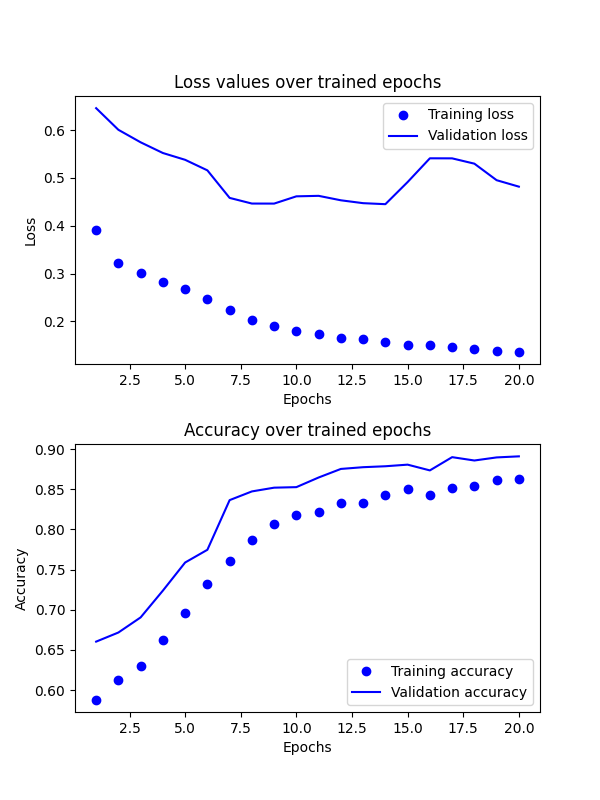

In [869]:
# plot the results 
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
num_of_epochs = range(1, len(loss_values)+1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize =(6, 8))
fig.subplots_adjust(hspace = 0.3)
ax1.plot(num_of_epochs, loss_values, 'bo', label='Training loss')
ax1.plot(num_of_epochs, val_loss_values, 'b', label='Validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.set_title('Loss values over trained epochs')

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
ax2.plot(num_of_epochs, acc_values, 'bo', label='Training accuracy')
ax2.plot(num_of_epochs, val_acc_values, 'b', label='Validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.set_title('Accuracy over trained epochs')

# Calc metrics for test data 

In [870]:

prediction_scores = model.predict(x_test)
prediction_labels = [0 if score <0.5 else 1 for score in prediction_scores]
prediction_labels = np.array(prediction_labels).astype(float)

tnr, tpr, acc, ba = calcTestAccAndRates(prediction_labels, y_test)

print("Metrics test data:")
print("TNR: ",np.round(tnr, 3))
print("TPR: ",np.round(tpr, 3)) 
print("Acc: ", np.round(acc, 3)) 


Metrics test data:
TNR:  0.886
TPR:  0.839
Acc:  0.862


# Single trial predictions training trials

In [871]:
true_labels = []
predicted_labels = []

for trials in lrp_epochs_train: 
    # true labels single trial 
    lrp_labels = np.zeros((trials.shape[1]))
    lrp_labels[-n_samp_features:] = 1.0
    true_labels.append(lrp_labels[:,])
    # single trial predictions 
    trial_prediction = model.predict(trials.T)
    trial_label = [0 if score <0.5 else 1 for score in trial_prediction]
    trial_label = np.array(trial_label)
    predicted_labels.append(trial_label)
    
#flatten the trial label 
true_labels = np.array(true_labels).flatten()
predicted_labels = np.array(predicted_labels).flatten()
tnr, tpr, acc, ba = calcTestAccAndRates(predicted_labels, true_labels)

print("Metrics train data:")
print("TNR: ",np.round(tnr, 3))
print("TPR: ",np.round(tpr, 3)) 
print("Acc: ", np.round(acc, 3)) 
print("BA: ", np.round(ba, 3)) 

Metrics train data:
TNR:  0.857
TPR:  0.938
Acc:  0.86
BA:  0.897


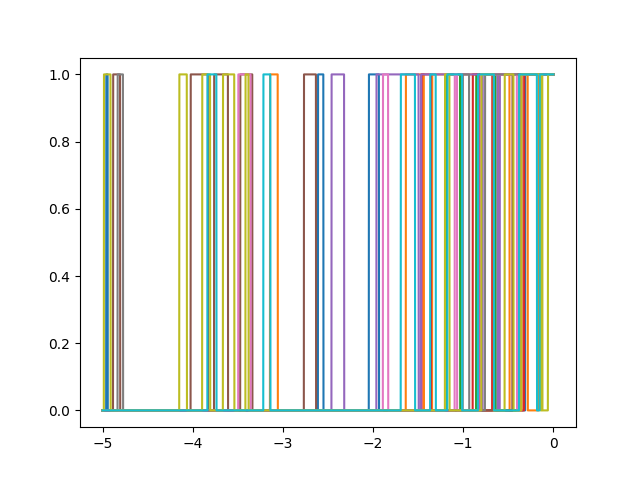

In [872]:
plt.figure()
for trial_nr in range(0, 10): 
    lrp_trial = lrp_epochs_train[trial_nr,:, :].T

    prediction_scores_lrp = model.predict(lrp_trial)
    prediction_labels_lrp= [0 if score <0.5 else 1 for score in prediction_scores_lrp]
    prediction_labels_lrp = np.array(prediction_labels_lrp)

    plt.plot(time_axis_eeg_batch, prediction_labels_lrp)

# Single trial predictions test trials

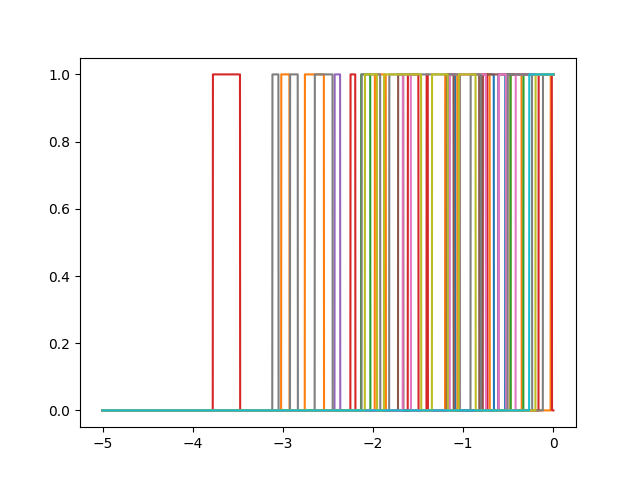

In [873]:
plt.figure()
for trial_nr in range(20,30): 
    lrp_trial = lrp_epochs_test[trial_nr,:, :].T

    prediction_scores_lrp = model.predict(lrp_trial)
    prediction_labels_lrp= [0 if score <0.5 else 1 for score in prediction_scores_lrp]
    prediction_labels_lrp = np.array(prediction_labels_lrp)

    plt.plot(time_axis_eeg_batch, prediction_labels_lrp)

In [874]:
true_labels = []
predicted_labels = []

for trials in lrp_epochs_test: 
    # true labels single trial 
    lrp_labels = np.zeros((trials.shape[1]))
    lrp_labels[-n_samp_features:] = 1.0
    true_labels.append(lrp_labels[:,])
    # single trial predictions 
    trial_prediction = model.predict(trials.T)
    trial_label = [0 if score <0.5 else 1 for score in trial_prediction]
    trial_label = np.array(trial_label)
    predicted_labels.append(trial_label)
    #flatten the trial label 
true_labels = np.array(true_labels).flatten()
predicted_labels = np.array(predicted_labels).flatten()
tnr, tpr, acc, ba = calcTestAccAndRates(predicted_labels, true_labels)

print("Metrics single trial data:")
print("TNR: ",np.round(tnr, 3))
print("TPR: ",np.round(tpr, 3)) 
print("Acc: ", np.round(acc, 3)) 
print("BA: ", np.round(ba, 3)) 

Metrics single trial data:
TNR:  0.811
TPR:  0.841
Acc:  0.812
BA:  0.826


# Windowwise evaluation of performances and predictions 